In [1]:
import sys
sys.path.append('../')

import torch
import pandas as pd
import optuna
import warnings
from copy import deepcopy
from torch.utils.data import DataLoader
from src.mypackage.data_preparation import prepare_statistical_data
from src.mypackage.torch_dataset import EnergyDataset
from src.mypackage.trainer import Trainer
from src.mypackage.rnn_models import RNNWithCNNModel
from src.mypackage.forecasting import dnn_forecast
from src.mypackage.evaluation import print_metrics, get_true_values
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED

warnings.filterwarnings("ignore")
set_seed(SEED)

In [2]:
# ========== データ読み込みとデータセット準備 ==========
df = pd.read_csv("../data/raw/PJME_hourly.csv")
_, tmp = prepare_statistical_data(df)
timesteps = tmp["Datetime"].copy()
del tmp
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

SEQ_LEN = 168
PRED_LEN = 24
SHIFT = 24
BATCH_SIZE = 32

# ========== データセット作成 ==========
dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="re-train")
retrain_dataset = deepcopy(dataset)
train_dataset = deepcopy(dataset)
train_dataset.mode_switch("train")
valid_dataset = deepcopy(dataset)
valid_dataset.mode_switch("val")
test_dataset = deepcopy(dataset)
test_dataset.mode_switch("test")

# DataLoader作成
retrain_loader = DataLoader(retrain_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Whole dataset size: {len(retrain_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Input features: {train_dataset[0][0].shape[1]}")


Dataset shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
Whole dataset size: 5654
Train dataset size: 5289
Val dataset size: 365
Test dataset size: 365
Input features: 19


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== ハイパーパラメータ設定 ==========
# 固定
NUM_EPOCHS = 100
INPUT_SIZE = train_dataset[0][0].shape[1]
EARLY_STOPPING_PATIENCE = 10
OUTPUT_SIZE = PRED_LEN

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    hidden_size = 2 ** trial.suggest_int("hidden_size", 4, 9)
    kernel_size = trial.suggest_int("kernel_size", 3, 7)
    num_conv_layers = trial.suggest_int("num_conv_layers", 1, 3)
    num_rnn_layers = trial.suggest_int("num_rnn_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    model_type = trial.suggest_categorical("model_type", ["RNN", "LSTM", "GRU"])

    model = RNNWithCNNModel(input_size=INPUT_SIZE, 
                            hidden_size=hidden_size, 
                            kernel_size=kernel_size,
                            num_conv_layers=num_conv_layers,
                            num_rnn_layers=num_rnn_layers, 
                            output_size=OUTPUT_SIZE, 
                            dropout=dropout,
                            rnn_type=model_type).to(device)

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        checkpoint_dir="../models/rnn_with_cnn_checkpoints"
    )
    history = trainer.train(num_epochs=NUM_EPOCHS, verbose=0)
    best_iteration = trainer.early_stopping.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    return min(history['val_loss'])

Using device: cuda


In [4]:
# パラメータ探索の実行
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50)
print(study.best_params)

[I 2026-07-20 07:04:07,732] A new study created in memory with name: no-name-0c303b93-341b-4dbd-9fe4-9bf9b7e87386
[I 2026-07-20 07:04:38,838] Trial 0 finished with value: 0.08463462566335996 and parameters: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'hidden_size': 8, 'kernel_size': 5, 'num_conv_layers': 1, 'num_rnn_layers': 1, 'dropout': 0.12323344486727979, 'model_type': 'RNN'}. Best is trial 0 with value: 0.08463462566335996.


Checkpoint loaded from ../models/rnn_with_cnn_checkpoints/best_model.pt


[I 2026-07-20 07:05:34,609] Trial 1 finished with value: 0.09435886610299349 and parameters: {'learning_rate': 1.1527987128232396e-05, 'weight_decay': 0.0008123245085588687, 'hidden_size': 8, 'kernel_size': 4, 'num_conv_layers': 1, 'num_rnn_layers': 1, 'dropout': 0.2216968971838151, 'model_type': 'RNN'}. Best is trial 0 with value: 0.08463462566335996.


Checkpoint loaded from ../models/rnn_with_cnn_checkpoints/best_model.pt


[I 2026-07-20 07:06:49,457] Trial 2 finished with value: 0.09080698589483897 and parameters: {'learning_rate': 0.000684792009557478, 'weight_decay': 2.62108787826544e-06, 'hidden_size': 5, 'kernel_size': 4, 'num_conv_layers': 2, 'num_rnn_layers': 4, 'dropout': 0.1798695128633439, 'model_type': 'LSTM'}. Best is trial 0 with value: 0.08463462566335996.


...

Checkpoint loaded from ../models/rnn_with_cnn_checkpoints/best_model.pt


[I 2026-07-20 07:48:57,740] Trial 48 finished with value: 0.09425725617135565 and parameters: {'learning_rate': 0.0007955160710529543, 'weight_decay': 0.0006028302473725125, 'hidden_size': 6, 'kernel_size': 3, 'num_conv_layers': 1, 'num_rnn_layers': 2, 'dropout': 0.2269455040898512, 'model_type': 'LSTM'}. Best is trial 36 with value: 0.08186485587308805.


Checkpoint loaded from ../models/rnn_with_cnn_checkpoints/best_model.pt


[I 2026-07-20 07:49:35,143] Trial 49 finished with value: 0.0912831147822241 and parameters: {'learning_rate': 0.00028748039487472044, 'weight_decay': 0.000406595412382834, 'hidden_size': 5, 'kernel_size': 4, 'num_conv_layers': 1, 'num_rnn_layers': 1, 'dropout': 0.1891447202470297, 'model_type': 'LSTM'}. Best is trial 36 with value: 0.08186485587308805.


Checkpoint loaded from ../models/rnn_with_cnn_checkpoints/best_model.pt
{'learning_rate': 0.00010376122495160678, 'weight_decay': 0.0008920697363906588, 'hidden_size': 8, 'kernel_size': 4, 'num_conv_layers': 1, 'num_rnn_layers': 1, 'dropout': 0.12167847615487813, 'model_type': 'LSTM'}


In [5]:
# モデルの再学習（1日予測）
model = RNNWithCNNModel(input_size=INPUT_SIZE,
                        hidden_size=2**study.best_params["hidden_size"], 
                        kernel_size=study.best_params["kernel_size"],
                        num_conv_layers=study.best_params["num_conv_layers"],
                        num_rnn_layers=study.best_params["num_rnn_layers"], 
                        output_size=OUTPUT_SIZE, 
                        dropout=study.best_params["dropout"],
                        rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=retrain_loader,
                  test_loader=test_loader,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_with_cnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [3/33] - Train Loss: 0.151159, Val Loss: nan - Train MAE: 0.300013, Val MAE: nan
Epoch [6/33] - Train Loss: 0.130929, Val Loss: nan - Train MAE: 0.276341, Val MAE: nan
Epoch [9/33] - Train Loss: 0.115005, Val Loss: nan - Train MAE: 0.258143, Val MAE: nan
Epoch [12/33] - Train Loss: 0.108348, Val Loss: nan - Train MAE: 0.249749, Val MAE: nan
Epoch [15/33] - Train Loss: 0.102631, Val Loss: nan - Train MAE: 0.244235, Val MAE: nan
Epoch [18/33] - Train Loss: 0.103715, Val Loss: nan - Train MAE: 0.245392, Val MAE: nan
Epoch [21/33] - Train Loss: 0.105459, Val Loss: nan - Train MAE: 0.246525, Val MAE: nan
Epoch [24/33] - Train Loss: 0.100498, Val Loss: nan - Train MAE: 0.242455, Val MAE: nan
Epoch [27/33] - Train Loss: 0.098606, Val Loss: nan - Train MAE: 0.238898, Val MAE: nan
Epoch [30/33] - Train Loss: 0.097362, Val Loss: nan - Train MAE: 0.237798, Val MAE: nan
Epoch [33/33] - Train Loss: 0.095029, Val Loss: nan - Train MAE: 0.233739, Val MAE: nan
No best model checkpoint found; sav

In [6]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_with_cnn_checkpoints/day_best_model.pth")
trainer.save_config("../models/rnn_with_cnn_checkpoints/day_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.101115
  Test MAE: 0.215585
  Test RMSE: 0.306287
Checkpoint saved to ../models/rnn_with_cnn_checkpoints/day_best_model.pth
Configuration saved to ../models/rnn_with_cnn_checkpoints/day_best_model_config.json


In [7]:
# 1週間予測用のデータセット
dataset_week = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=7*PRED_LEN, mode="re-train")
test_dataset_week = deepcopy(dataset_week)
test_dataset_week.mode_switch("test")

train_loader_week = DataLoader(dataset_week, batch_size=BATCH_SIZE, shuffle=True)
test_loader_week = DataLoader(test_dataset_week, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# モデルの再学習（1週間予測）
model = RNNWithCNNModel(input_size=INPUT_SIZE,
                        hidden_size=2**study.best_params["hidden_size"], 
                        kernel_size=study.best_params["kernel_size"],
                        num_conv_layers=study.best_params["num_conv_layers"],
                        num_rnn_layers=study.best_params["num_rnn_layers"], 
                        output_size=7*PRED_LEN, 
                        dropout=study.best_params["dropout"],
                        rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_week,
                  test_loader=test_loader_week,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_with_cnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [3/33] - Train Loss: 0.293966, Val Loss: nan - Train MAE: 0.416504, Val MAE: nan
Epoch [6/33] - Train Loss: 0.254905, Val Loss: nan - Train MAE: 0.382787, Val MAE: nan
Epoch [9/33] - Train Loss: 0.237672, Val Loss: nan - Train MAE: 0.367068, Val MAE: nan
Epoch [12/33] - Train Loss: 0.228049, Val Loss: nan - Train MAE: 0.358909, Val MAE: nan
Epoch [15/33] - Train Loss: 0.224220, Val Loss: nan - Train MAE: 0.356118, Val MAE: nan
Epoch [18/33] - Train Loss: 0.220444, Val Loss: nan - Train MAE: 0.353090, Val MAE: nan
Epoch [21/33] - Train Loss: 0.220637, Val Loss: nan - Train MAE: 0.352768, Val MAE: nan
Epoch [24/33] - Train Loss: 0.214260, Val Loss: nan - Train MAE: 0.347946, Val MAE: nan
Epoch [27/33] - Train Loss: 0.213070, Val Loss: nan - Train MAE: 0.346824, Val MAE: nan
Epoch [30/33] - Train Loss: 0.210712, Val Loss: nan - Train MAE: 0.343823, Val MAE: nan
Epoch [33/33] - Train Loss: 0.204266, Val Loss: nan - Train MAE: 0.338483, Val MAE: nan
No best model checkpoint found; sav

In [ ]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_with_cnn_checkpoints/week_best_model.pth")
trainer.save_config("../models/rnn_with_cnn_checkpoints/week_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.291836
  Test MAE: 0.397653
  Test RMSE: 0.540045
Checkpoint saved to ../models/rnn_with_cnn_checkpoints/week_best_model.pth
Configuration saved to ../models/rnn_with_cnn_checkpoints/week_best_model_config.json


In [10]:
# 1か月予測用のデータセット
dataset_month = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=30*PRED_LEN, mode="re-train")
test_dataset_month = deepcopy(dataset_month)
test_dataset_month.mode_switch("test")

train_loader_month = DataLoader(dataset_month, batch_size=BATCH_SIZE, shuffle=True)
test_loader_month = DataLoader(test_dataset_month, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# モデルの再学習（1か月予測）
model = RNNWithCNNModel(input_size=INPUT_SIZE,
                        hidden_size=2**study.best_params["hidden_size"], 
                        kernel_size=study.best_params["kernel_size"],
                        num_conv_layers=study.best_params["num_conv_layers"], 
                        num_rnn_layers=study.best_params["num_rnn_layers"], 
                        output_size=30*PRED_LEN,  # 1か月予測のため出力サイズを変更
                        dropout=study.best_params["dropout"],
                        rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_month,
                  test_loader=test_loader_month,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_with_cnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [3/33] - Train Loss: 0.335492, Val Loss: nan - Train MAE: 0.447792, Val MAE: nan
Epoch [6/33] - Train Loss: 0.287087, Val Loss: nan - Train MAE: 0.407695, Val MAE: nan
Epoch [9/33] - Train Loss: 0.269275, Val Loss: nan - Train MAE: 0.392497, Val MAE: nan
Epoch [12/33] - Train Loss: 0.264874, Val Loss: nan - Train MAE: 0.389109, Val MAE: nan
Epoch [15/33] - Train Loss: 0.258091, Val Loss: nan - Train MAE: 0.383634, Val MAE: nan
Epoch [18/33] - Train Loss: 0.254492, Val Loss: nan - Train MAE: 0.381110, Val MAE: nan
Epoch [21/33] - Train Loss: 0.249480, Val Loss: nan - Train MAE: 0.376975, Val MAE: nan
Epoch [24/33] - Train Loss: 0.248992, Val Loss: nan - Train MAE: 0.376110, Val MAE: nan
Epoch [27/33] - Train Loss: 0.248278, Val Loss: nan - Train MAE: 0.375667, Val MAE: nan
Epoch [30/33] - Train Loss: 0.247036, Val Loss: nan - Train MAE: 0.374553, Val MAE: nan
Epoch [33/33] - Train Loss: 0.243558, Val Loss: nan - Train MAE: 0.371828, Val MAE: nan
No best model checkpoint found; sav

In [12]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_with_cnn_checkpoints/month_best_model.pth")
trainer.save_config("../models/rnn_with_cnn_checkpoints/month_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.298144
  Test MAE: 0.408050
  Test RMSE: 0.546026
Checkpoint saved to ../models/rnn_with_cnn_checkpoints/month_best_model.pth
Configuration saved to ../models/rnn_with_cnn_checkpoints/month_best_model_config.json


In [13]:
# 1年予測用のデータセット
dataset_year = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=365*PRED_LEN, mode="re-train")
test_dataset_year = deepcopy(dataset_year)
test_dataset_year.mode_switch("test")

train_loader_year = DataLoader(dataset_year, batch_size=BATCH_SIZE, shuffle=True)
test_loader_year = DataLoader(test_dataset_year, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
# モデルの再学習（1年予測）
model = RNNWithCNNModel(input_size=INPUT_SIZE,
                        hidden_size=2**study.best_params["hidden_size"], 
                        kernel_size=study.best_params["kernel_size"],
                        num_conv_layers=study.best_params["num_conv_layers"], 
                        num_rnn_layers=study.best_params["num_rnn_layers"], 
                        output_size=365*PRED_LEN,  # 1年予測のため出力サイズを変更
                        dropout=study.best_params["dropout"],
                        rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_year,
                  test_loader=test_loader_year,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_with_cnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [3/33] - Train Loss: 0.436782, Val Loss: nan - Train MAE: 0.509035, Val MAE: nan
Epoch [6/33] - Train Loss: 0.350298, Val Loss: nan - Train MAE: 0.450434, Val MAE: nan
Epoch [9/33] - Train Loss: 0.333482, Val Loss: nan - Train MAE: 0.438870, Val MAE: nan
Epoch [12/33] - Train Loss: 0.329031, Val Loss: nan - Train MAE: 0.435214, Val MAE: nan
Epoch [15/33] - Train Loss: 0.325592, Val Loss: nan - Train MAE: 0.432390, Val MAE: nan
Epoch [18/33] - Train Loss: 0.324112, Val Loss: nan - Train MAE: 0.431112, Val MAE: nan
Epoch [21/33] - Train Loss: 0.321820, Val Loss: nan - Train MAE: 0.429254, Val MAE: nan
Epoch [24/33] - Train Loss: 0.323666, Val Loss: nan - Train MAE: 0.430571, Val MAE: nan
Epoch [27/33] - Train Loss: 0.322659, Val Loss: nan - Train MAE: 0.429719, Val MAE: nan
Epoch [30/33] - Train Loss: 0.322638, Val Loss: nan - Train MAE: 0.429731, Val MAE: nan
Epoch [33/33] - Train Loss: 0.322762, Val Loss: nan - Train MAE: 0.429643, Val MAE: nan
No best model checkpoint found; sav

In [15]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_with_cnn_checkpoints/year_best_model.pth")
trainer.save_config("../models/rnn_with_cnn_checkpoints/year_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.334799
  Test MAE: 0.447061
  Test RMSE: 0.578619
Checkpoint saved to ../models/rnn_with_cnn_checkpoints/year_best_model.pth
Configuration saved to ../models/rnn_with_cnn_checkpoints/year_best_model_config.json


In [16]:
# チェックポイントの読み込みと再学習
checkpoint_day = torch.load("../models/rnn_with_cnn_checkpoints/day_best_model.pth", map_location=device)
params_day = checkpoint_day["model_config"]
model_day = RNNWithCNNModel(**params_day).to(device)
model_day.load_state_dict(checkpoint_day["model_state_dict"])

checkpoint_week = torch.load("../models/rnn_with_cnn_checkpoints/week_best_model.pth", map_location=device)
params_week = checkpoint_week["model_config"]
model_week = RNNWithCNNModel(**params_week).to(device)
model_week.load_state_dict(checkpoint_week["model_state_dict"])

checkpoint_month = torch.load("../models/rnn_with_cnn_checkpoints/month_best_model.pth", map_location=device)
params_month = checkpoint_month["model_config"]
model_month = RNNWithCNNModel(**params_month).to(device)
model_month.load_state_dict(checkpoint_month["model_state_dict"])

checkpoint_year = torch.load("../models/rnn_with_cnn_checkpoints/year_best_model.pth", map_location=device)
params_year = checkpoint_year["model_config"]
model_year = RNNWithCNNModel(**params_year).to(device)
model_year.load_state_dict(checkpoint_year["model_state_dict"])

<All keys matched successfully>

In [17]:
y_true = get_true_values(test_loader, dataset)

y_pred_day = dnn_forecast(model_day, test_loader, dataset, device)
y_pred_week = dnn_forecast(model_week, test_loader_week, dataset, device)[-len(y_true):]
y_pred_month = dnn_forecast(model_month, test_loader_month, dataset, device)[-len(y_true):]
y_pred_year = dnn_forecast(model_year, test_loader_year, dataset, device)

In [18]:
print_metrics(y_true, y_pred_day, "RNN Forecast (1 Day)")
print_metrics(y_true, y_pred_week, "RNN Forecast (1 Week)")
print_metrics(y_true, y_pred_month, "RNN Forecast (1 Month)")
print_metrics(y_true, y_pred_year, "RNN Forecast (1 Year)")

RNN Forecast (1 Day):
MAE: 1396.75
RMSE: 2044.10
MAPE: 4.24%

RNN Forecast (1 Week):
MAE: 3606.70
RMSE: 4755.26
MAPE: 11.51%

RNN Forecast (1 Month):
MAE: 4075.20
RMSE: 5230.02
MAPE: 12.94%

RNN Forecast (1 Year):
MAE: 3622.07
RMSE: 4665.83
MAPE: 11.65%



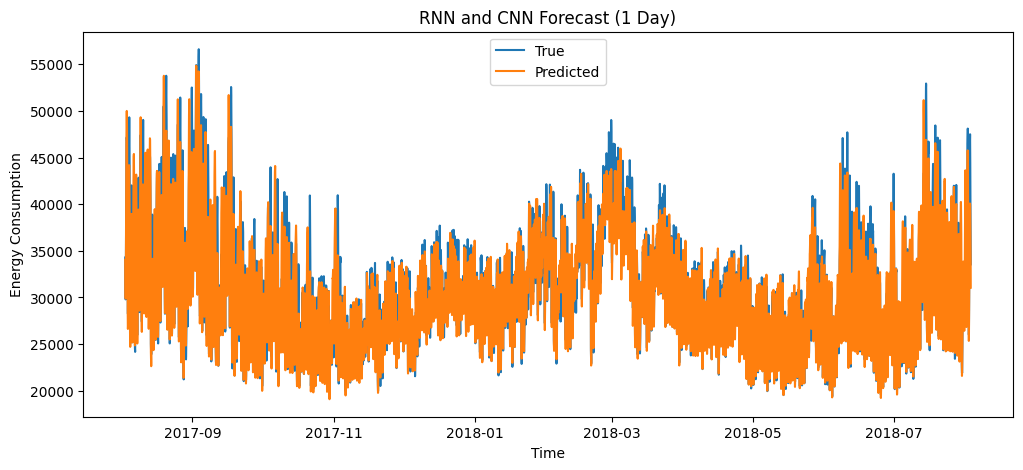

In [19]:
plot_forecast(y_true, y_pred_day, timesteps, "RNN and CNN Forecast (1 Day)")

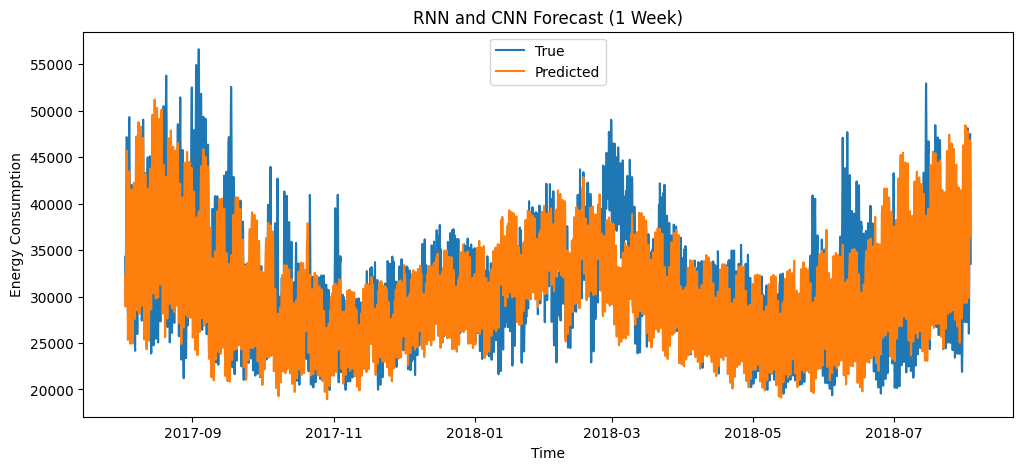

In [20]:
plot_forecast(y_true, y_pred_week, timesteps, "RNN and CNN Forecast (1 Week)")

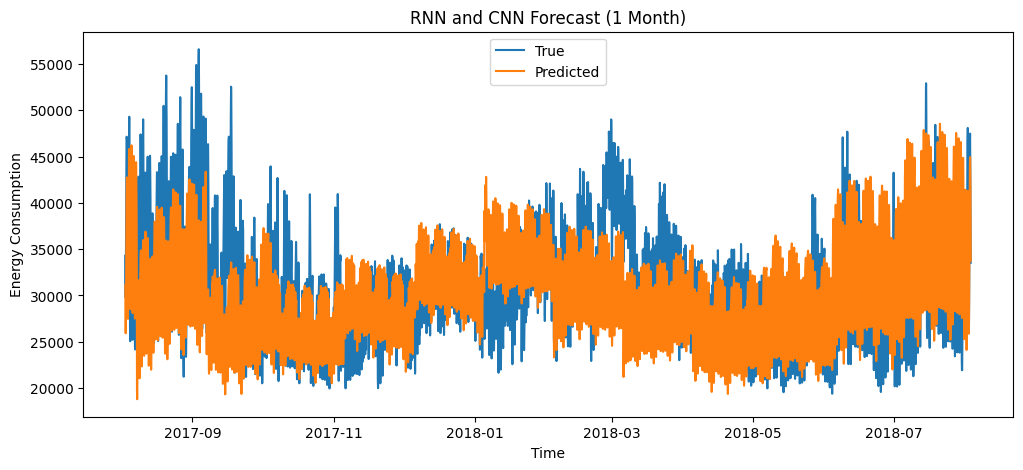

In [21]:
plot_forecast(y_true, y_pred_month, timesteps, "RNN and CNN Forecast (1 Month)")

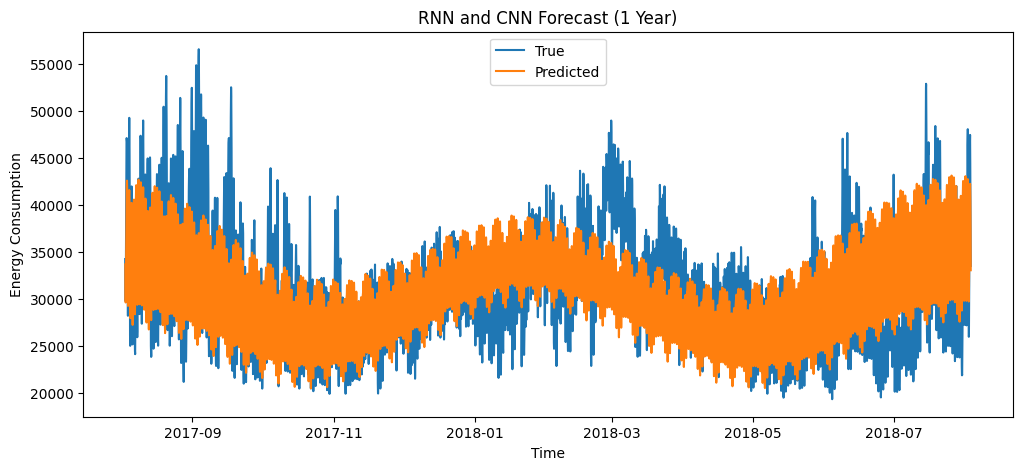

In [22]:
plot_forecast(y_true, y_pred_year, timesteps, "RNN and CNN Forecast (1 Year)")